In [113]:
#Code Block 1
## import libraries

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

plt.style.use('seaborn-v0_8')
sns.set_style('whitegrid')
%matplotlib inline

In [114]:
#Code Block 2
## load the cleaned data

data_clean = pd.read_csv('../../Data/Hennepin/cleaned/cleaned_mortgage_covenant_data.csv')
display(data_clean.head())
data_clean.info()

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,27037060737,Race Not Available,6,185000.0,195000.0,96.0,6.125,40.37,73.48,10,0.0,False,0
1,2023,27141030504,Race Not Available,6,375000.0,385000.0,96.0,6.625,10.64,121.26,10,0.0,False,0
2,2023,27023950400,Race Not Available,6,105000.0,105000.0,96.0,6.125,8.92,90.13,10,0.0,False,0
3,2023,27171100101,Race Not Available,6,285000.0,285000.0,96.0,6.750,13.27,104.37,10,0.0,False,0
4,2023,27159480100,Race Not Available,6,175000.0,175000.0,96.0,6.875,5.87,82.22,10,0.0,False,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100931 entries, 0 to 100930
Data columns (total 14 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   activity_year                      100931 non-null  int64  
 1   census_tract                       100931 non-null  object 
 2   derived_race                       100931 non-null  object 
 3   action_taken                       100931 non-null  int64  
 4   loan_amount                        100931 non-null  float64
 5   property_value                     100931 non-null  float64
 6   income                             100931 non-null  float64
 7   interest_rate                      78125 non-null   float64
 8   tract_minority_population_percent  100931 non-null  float64
 9   tract_to_msa_income_percentage     100931 non-null  float64
 10  denial_reason-1                    100931 non-null  int64  
 11  covenant_count                     1009

Analysis of Property Value vs. Covenant Density

In [115]:
#Code Block 3
## property value vs. covenant density

data_clean.groupby('covenant_density')['property_value'].describe()

,count,mean,std,min,25%,50%,75%,max
covenant_density,,,,,,,,
0,89762.0,376651.589760,1.106256e+06,5000.0,255000.0,325000.0,405000.0,111325000.0
High (101-200),1720.0,511220.930233,1.601397e+06,55000.0,315000.0,345000.0,475000.0,64405000.0
Low (1-50),4537.0,403155.168614,3.127115e+05,5000.0,275000.0,325000.0,405000.0,7625000.0
Medium (51-100),1772.0,530558.690745,1.552490e+06,55000.0,295000.0,325000.0,485000.0,48055000.0
Very High (>200),3140.0,479095.541401,4.563230e+05,25000.0,325000.0,355000.0,495000.0,14205000.0


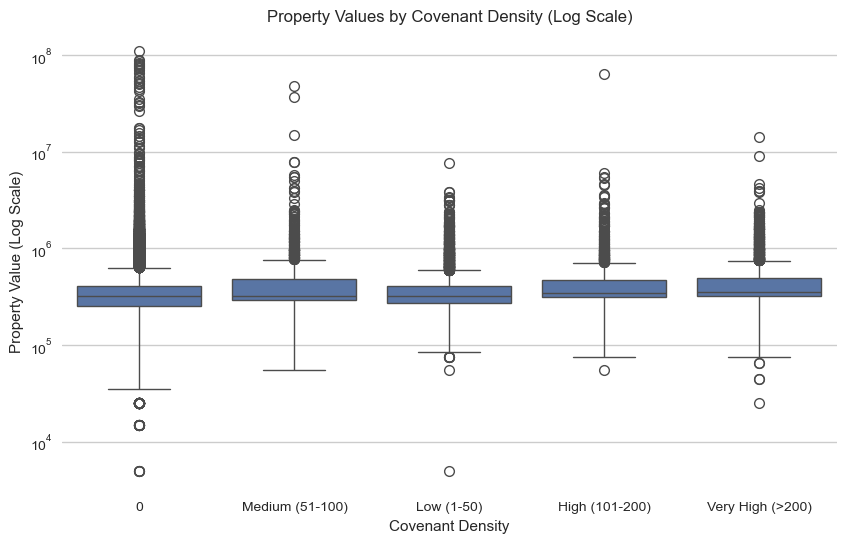

In [116]:
#Code Block 4
## visualization for property value vs. covenant density
if not os.path.exists('../../Analysis/figures'):
    os.makedirs('../../Analysis/figures')

plt.figure(figsize=(10,6))

sns.boxplot(data=data_clean, x='covenant_density', y='property_value')

plt.yscale('log')
plt.title("Property Values by Covenant Density (Log Scale)")
plt.xlabel("Covenant Density")
plt.ylabel("Property Value (Log Scale)")
## save the figure
plt.savefig('../../Analysis/figures/property_value_by_covenant_density.png', dpi=300, bbox_inches='tight')
plt.show()

derived_race
White               0.756063
Joint               0.744129
Asian               0.707705
Multiracial         0.659259
Native American     0.622003
Black               0.604155
Pacific Islander    0.566372
Unknown             0.405812
Name: was_approved, dtype: float64

/var/folders/mm/xkwn8c6n2djgfy47v6p2myf00000gn/T/ipykernel_71085/1690247890.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_clean, x='derived_race', y='was_approved', palette='viridis', order=data_clean.groupby('derived_race')['was_approved'].mean().sort_values(ascending=False).index)


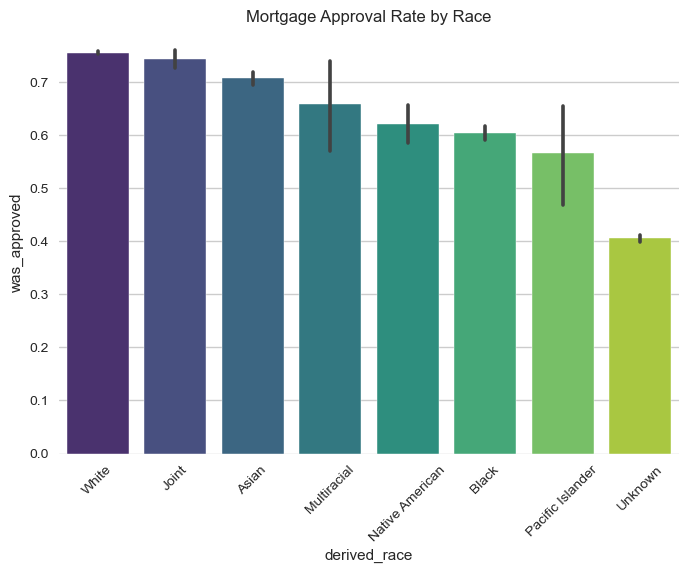

In [117]:
#Code Block 5
## approval rates grouped by derived race
race_clean_map = {
    "White": "White",
    "Black or African American": "Black",
    "Asian": "Asian",
    "American Indian or Alaska Native": "Native American",
    "Native Hawaiian or Other Pacific Islander": "Pacific Islander",
    "2 or more minority races": "Multiracial",
    "Joint": "Joint",
    "Free Form Text Only": "Unknown",
    "Race Not Available": "Unknown"
}

data_clean['derived_race'] = data_clean['derived_race'].replace(race_clean_map)

display(data_clean.groupby('derived_race')['was_approved'].mean().sort_values(ascending=False))

sns.barplot(data=data_clean, x='derived_race', y='was_approved', palette='viridis', order=data_clean.groupby('derived_race')['was_approved'].mean().sort_values(ascending=False).index)
plt.title("Mortgage Approval Rate by Race")
plt.xticks(rotation=45)
## save the figure
plt.savefig("../../Analysis/figures/mortgage_approval_rate_by_race.png", dpi=300, bbox_inches='tight')
plt.show()

Detect Proxy Variables

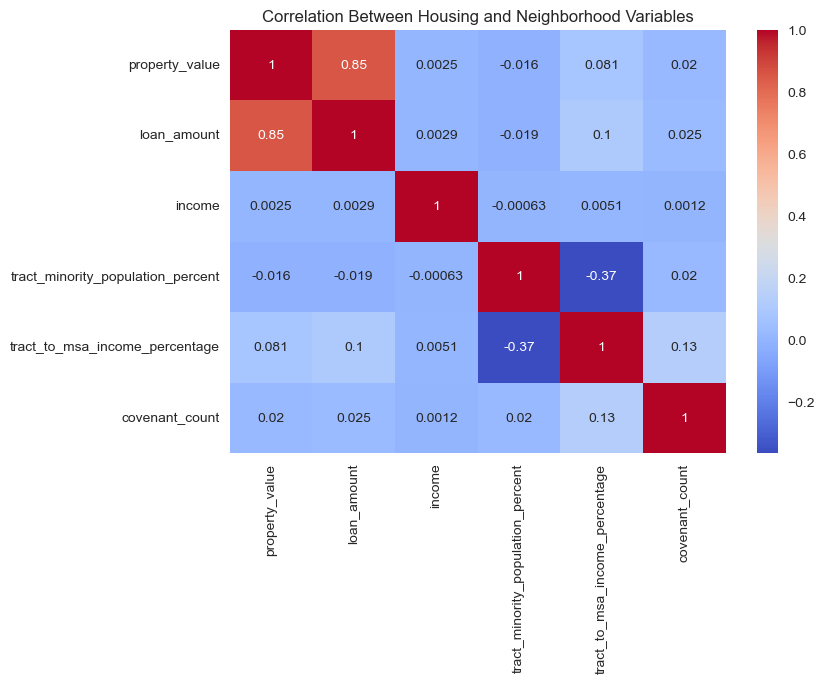

In [118]:
#Code Block 6
## correlation analysis for proxy variables

cols = [
    'property_value',
    'loan_amount',
    'income',
    'tract_minority_population_percent',
    'tract_to_msa_income_percentage',
    'covenant_count'
]

data_clean[cols].corr()

sns.heatmap(data_clean[cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Housing and Neighborhood Variables")
## save the figure
plt.savefig("../../Analysis/figures/correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

Lending in Covenanted vs. Non-Covenanted Areas

has_covenants
False    0.663867
True     0.671054
Name: was_approved, dtype: float64

has_covenants
False    302042.401016
True     383043.692363
Name: loan_amount, dtype: float64

has_covenants
False    376651.589760
True     461359.566658
Name: property_value, dtype: float64

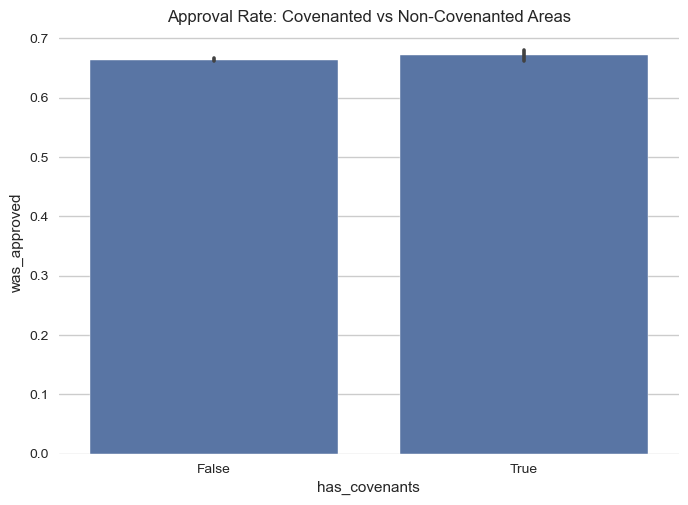

In [119]:
#Code Block 7
## compare lending in covenanted vs non-covenanted tracts

### binary variable for whether tract has any covenants
data_clean['has_covenants'] = data_clean['covenant_count'] > 0

### compare approval rates
display(data_clean.groupby('has_covenants')['was_approved'].mean())

### compare loan amounts
display(data_clean.groupby('has_covenants')['loan_amount'].mean())

### compare property values
display(data_clean.groupby('has_covenants')['property_value'].mean())

### visualize approval rates by covenant presence
sns.barplot(data=data_clean, x='has_covenants', y='was_approved')
plt.title("Approval Rate: Covenanted vs Non-Covenanted Areas")
## save the figure
plt.savefig("../../Analysis/figures/approval_rate_by_covenant_presence.png", dpi=300, bbox_inches='tight')
plt.show()

/var/folders/mm/xkwn8c6n2djgfy47v6p2myf00000gn/T/ipykernel_71085/1302600830.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_clean, x='covenant_density', y='was_approved', palette='viridis')


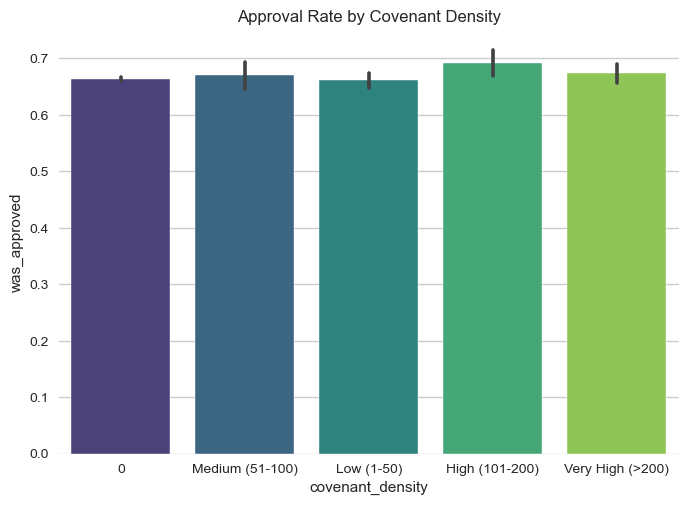

In [120]:
#Code Block 8
## approval rate based on covenant density categories
sns.barplot(data=data_clean, x='covenant_density', y='was_approved', palette='viridis')
plt.title("Approval Rate by Covenant Density")
## save the figure
plt.savefig("../../Analysis/figures/approval_rate_by_covenant_density.png", dpi=300, bbox_inches='tight')
plt.show()

In [121]:
#Code Block 8
## pivot table for approval rates by race and covenant presence
column_order = ['0', 'Low (1-50)', 'Medium (51-100)', 'High (101-200)', 'Very High (>200)']

pivot_table = pd.pivot_table(
    data_clean,
    values='was_approved',
    index='derived_race',
    columns='covenant_density',
    aggfunc='mean'
)
pivot_table = pivot_table[column_order]
display(pivot_table)

covenant_density,0,Low (1-50),Medium (51-100),High (101-200),Very High (>200)
derived_race,,,,,
Asian,0.707331,0.689394,0.787500,0.741935,0.695652
Black,0.607475,0.578454,0.592233,0.608696,0.574257
Joint,0.738878,0.772414,0.653846,0.828125,0.806122
Multiracial,0.649573,0.571429,1.000000,0.600000,1.000000
Native American,0.622222,0.558824,0.666667,0.666667,0.666667
Pacific Islander,0.554455,0.666667,NaN,0.500000,0.750000
Unknown,0.401267,0.464029,0.405405,0.447761,0.417800
White,0.754718,0.753737,0.778605,0.773451,0.775687


Logistic Regression

In [122]:
#Code Block 9
## logistic regression prep
import statsmodels.formula.api as smf
if not os.path.exists('../../Analysis/models'):
    os.makedirs('../../Analysis/models')

### drop missing interest rate values
data_model = data_clean.dropna(subset=['interest_rate'])
data_model['was_approved'] = data_model['was_approved'].astype(int)

model = smf.logit(formula = """
                  was_approved ~
                  C(derived_race) +
                  income +
                  loan_amount +
                  property_value +
                  interest_rate +
                  tract_minority_population_percent +
                  tract_to_msa_income_percentage +
                  covenant_count
                  """,
        data = data_model).fit()
## save the model
model.save('../../Analysis/models/logistic_regression_model.pkl')
print(model.summary())

/var/folders/mm/xkwn8c6n2djgfy47v6p2myf00000gn/T/ipykernel_71085/228777327.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_model['was_approved'] = data_model['was_approved'].astype(int)


Optimization terminated successfully.
         Current function value: 0.372902
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:           was_approved   No. Observations:                78125
Model:                          Logit   Df Residuals:                    78110
Method:                           MLE   Df Model:                           14
Date:                Tue, 10 Mar 2026   Pseudo R-squ.:                  0.2633
Time:                        13:57:28   Log-Likelihood:                -29133.
converged:                       True   LL-Null:                       -39543.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               1.4270      0.096 

In [123]:
#Code Block 10
## extract odds ratios

odds_ratios = np.exp(model.params)
print(odds_ratios)

Intercept                              4.166372
C(derived_race)[T.Black]               0.524777
C(derived_race)[T.Joint]               0.848571
C(derived_race)[T.Multiracial]         1.204389
C(derived_race)[T.Native American]     0.780122
C(derived_race)[T.Pacific Islander]    0.339195
C(derived_race)[T.Unknown]             0.063863
C(derived_race)[T.White]               0.975171
income                                 1.007696
loan_amount                            0.999995
property_value                         1.000004
interest_rate                          0.998519
tract_minority_population_percent      1.000789
tract_to_msa_income_percentage         1.002060
covenant_count                         0.999725
dtype: float64


Logistic Regression for Covenant Density

In [124]:
#Code Block 11
## logistic regression with covenant density
model2 = smf.logit(
    """
    was_approved ~ 
    C(derived_race) +
    income +
    loan_amount +
    property_value +
    interest_rate +
    tract_minority_population_percent +
    tract_to_msa_income_percentage +
    C(covenant_density)
    """,
    data=data_model
).fit()

print(model2.summary())
## save the model
model2.save('../../Analysis/models/logistic_regression_cov_density.pkl')

odds_ratios = np.exp(model2.params)
print(odds_ratios)

Optimization terminated successfully.
         Current function value: 0.372826
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:           was_approved   No. Observations:                78125
Model:                          Logit   Df Residuals:                    78107
Method:                           MLE   Df Model:                           17
Date:                Tue, 10 Mar 2026   Pseudo R-squ.:                  0.2634
Time:                        13:57:28   Log-Likelihood:                -29127.
converged:                       True   LL-Null:                       -39543.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                   1.4040

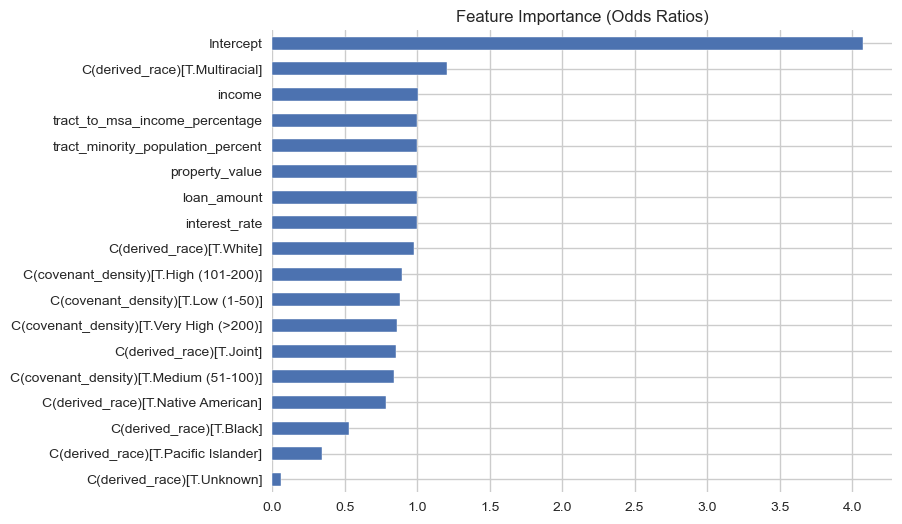

In [125]:
#Code Block 12
## feature importance analysis for log reg

odds_ratios.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance (Odds Ratios)")
## save the figure
plt.savefig("../../Analysis/figures/feature_importance_odds_ratios.png", dpi=300, bbox_inches='tight')
plt.show()

In [126]:
#Code Block 13
## check for multicollinearity with VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

# select only numeric columns
X = data_clean.select_dtypes(include=['float64','int64'])

print(X.isna().sum())

X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                  for i in range(len(X.columns))]

vif_data

activity_year                            0
action_taken                             0
loan_amount                              0
property_value                           0
income                                   0
interest_rate                        22806
tract_minority_population_percent        0
tract_to_msa_income_percentage           0
denial_reason-1                          0
covenant_count                           0
dtype: int64


,feature,VIF
0,activity_year,52.497172
1,action_taken,1.016259
2,loan_amount,20.492779
3,property_value,20.389968
4,income,1.085018
5,interest_rate,1.008787
6,tract_minority_population_percent,1.218469
7,tract_to_msa_income_percentage,1.308127
8,denial_reason-1,1.001331
9,covenant_count,1.026892


## Data Bias

In [127]:
#Code Block 14
## property value disparities

print("\nAverage Property Value by Covenant Density:\n")
display(data_clean.groupby('covenant_density')['property_value'].mean())

## income disparities
print("Average Income by Covenant Density:\n")
display(data_clean.groupby('covenant_density')['income'].mean())

## racial distribution
print("Racial Distribution by Covenant Density:\n")
display(pd.crosstab(data_clean['derived_race'], data_clean['covenant_density']))
print("Racial Distribution by Covenant Density (Normalized):\n")
display(pd.crosstab(data_clean['derived_race'], data_clean['covenant_density'], normalize='columns'))

## loan size differences
print("Average Loan Amount by Covenant Density:\n")
display(data_clean.groupby('covenant_density')['loan_amount'].mean())


Average Property Value by Covenant Density:



covenant_density
0                   376651.589760
High (101-200)      511220.930233
Low (1-50)          403155.168614
Medium (51-100)     530558.690745
Very High (>200)    479095.541401
Name: property_value, dtype: float64

Average Income by Covenant Density:



covenant_density
0                   140.829482
High (101-200)      169.474419
Low (1-50)          134.273088
Medium (51-100)     158.142777
Very High (>200)    171.630892
Name: income, dtype: float64

Racial Distribution by Covenant Density:



covenant_density,0,High (101-200),Low (1-50),Medium (51-100),Very High (>200)
derived_race,,,,,
Asian,5361,62,264,80,138
Black,4522,46,427,103,101
Joint,2068,64,145,52,98
Multiracial,117,5,7,3,3
Native American,630,9,34,15,21
Pacific Islander,101,2,6,0,4
Unknown,20049,402,1112,444,809
White,56914,1130,2542,1075,1966


Racial Distribution by Covenant Density (Normalized):



covenant_density,0,High (101-200),Low (1-50),Medium (51-100),Very High (>200)
derived_race,,,,,
Asian,0.059725,0.036047,0.058188,0.045147,0.043949
Black,0.050378,0.026744,0.094115,0.058126,0.032166
Joint,0.023039,0.037209,0.031959,0.029345,0.031210
Multiracial,0.001303,0.002907,0.001543,0.001693,0.000955
Native American,0.007019,0.005233,0.007494,0.008465,0.006688
Pacific Islander,0.001125,0.001163,0.001322,0.000000,0.001274
Unknown,0.223357,0.233721,0.245096,0.250564,0.257643
White,0.634054,0.656977,0.560282,0.606659,0.626115


Average Loan Amount by Covenant Density:



covenant_density
0                   302042.401016
High (101-200)      421197.674419
Low (1-50)          344440.158695
Medium (51-100)     420513.544018
Very High (>200)    396777.070064
Name: loan_amount, dtype: float64

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


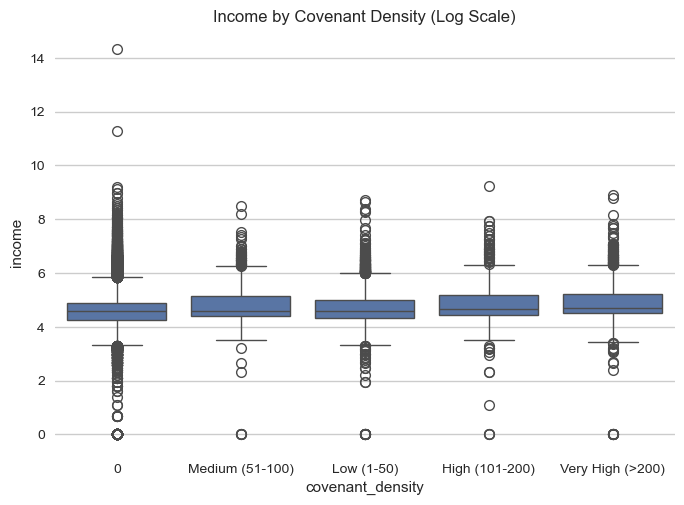

In [128]:
#Code Block 15
## visualization for income disparities

data_viz = data_clean.copy()
data_viz['income'] = np.log(data_viz['income'] + 1)
sns.boxplot(x='covenant_density', y='income', data=data_viz)
plt.title("Income by Covenant Density (Log Scale)")
## save the figure
plt.savefig("../../Analysis/figures/income_by_covenant_density.png", dpi=300, bbox_inches='tight')
plt.show()

## Algorithmic Bias

In [129]:
#Code Block 16
## algorithmic bias analysis - does lending model reproduce or amplify inequalities

### approval rates by covenant density
print("\nApproval Rates by Covenant Density:\n")
display(data_clean.groupby('covenant_density')['was_approved'].mean())

### approval rates by race
print("Approval Rates by Race:\n")
display(data_clean.groupby('derived_race')['was_approved'].mean())


Approval Rates by Covenant Density:



covenant_density
0                   0.663867
High (101-200)      0.692442
Low (1-50)          0.661230
Medium (51-100)     0.670429
Very High (>200)    0.673885
Name: was_approved, dtype: float64

Approval Rates by Race:



derived_race
Asian               0.707705
Black               0.604155
Joint               0.744129
Multiracial         0.659259
Native American     0.622003
Pacific Islander    0.566372
Unknown             0.405812
White               0.756063
Name: was_approved, dtype: float64

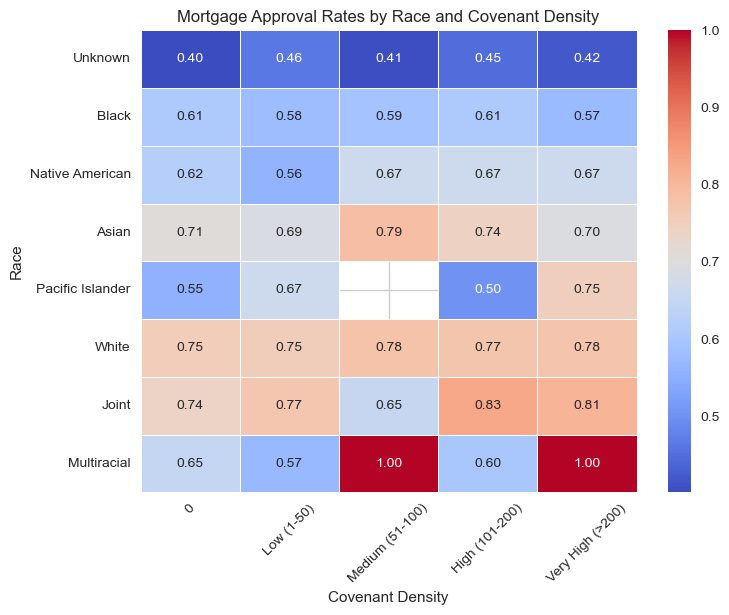

In [130]:
#Code Block 17
## visualization for approval rates by race and covenant density

plt.figure(figsize=(8,6))
pivot_table = pivot_table.sort_values(by=pivot_table.columns[-1])

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Mortgage Approval Rates by Race and Covenant Density")
plt.xlabel("Covenant Density")
plt.xticks(rotation=45)
plt.ylabel("Race")
### save the figure
plt.savefig("../../Analysis/figures/approval_rates_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

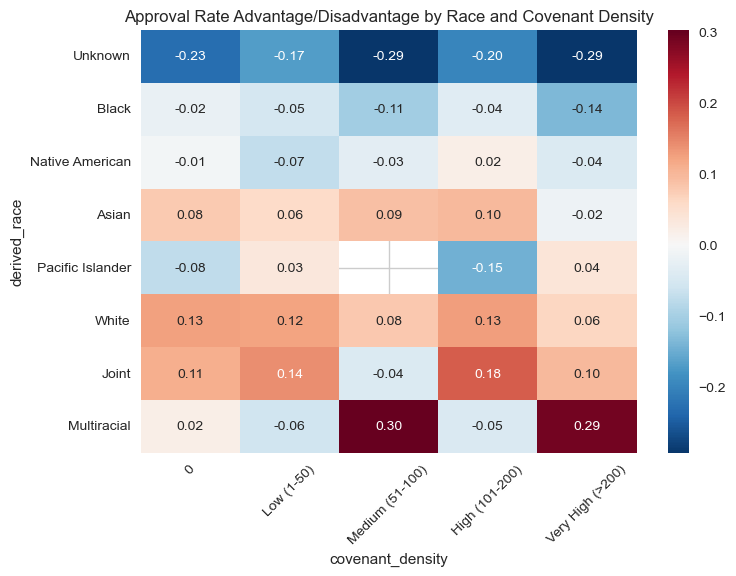

In [131]:
#Code Block 18
## pivot table advantage vs disadvantage analysis

pivot_diff = pivot_table - pivot_table.mean()

sns.heatmap(
    pivot_diff,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f"
)
plt.xticks(rotation=45)
plt.title("Approval Rate Advantage/Disadvantage by Race and Covenant Density")
## save the figure
plt.savefig("../../Analysis/figures/approval_rate_advantage_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [132]:
#Code Block 19
## risk proxy investigation

data_clean[['covenant_count','property_value','income','loan_amount']].corr()

,covenant_count,property_value,income,loan_amount
covenant_count,1.000000,0.019796,0.001153,0.024809
property_value,0.019796,1.000000,0.002504,0.854953
income,0.001153,0.002504,1.000000,0.002907
loan_amount,0.024809,0.854953,0.002907,1.000000


## Full Logistic Regression Analysis

In [133]:
#Code Block 20
## examine the data

data_clean.info()
data_clean.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100931 entries, 0 to 100930
Data columns (total 15 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   activity_year                      100931 non-null  int64  
 1   census_tract                       100931 non-null  object 
 2   derived_race                       100931 non-null  object 
 3   action_taken                       100931 non-null  int64  
 4   loan_amount                        100931 non-null  float64
 5   property_value                     100931 non-null  float64
 6   income                             100931 non-null  float64
 7   interest_rate                      78125 non-null   float64
 8   tract_minority_population_percent  100931 non-null  float64
 9   tract_to_msa_income_percentage     100931 non-null  float64
 10  denial_reason-1                    100931 non-null  int64  
 11  covenant_count                     1009

,activity_year,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count
count,100931.0,100931.000000,1.009310e+05,1.009310e+05,1.009310e+05,78125.000000,100931.000000,100931.000000,100931.000000,100931.000000
mean,2023.0,2.309528,3.110060e+05,3.860254e+05,1.422851e+02,6.575084,22.874029,101.813583,48.624763,17.408101
std,0.0,1.950185,7.617088e+05,1.089132e+06,5.205804e+03,1.273054,17.292952,32.381060,203.617075,84.973673
min,2023.0,1.000000,5.000000e+03,5.000000e+03,-3.415700e+04,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2023.0,1.000000,1.750000e+05,2.550000e+05,7.100000e+01,6.125000,10.140000,82.070000,10.000000,0.000000
50%,2023.0,1.000000,2.650000e+05,3.250000e+05,9.600000e+01,6.625000,18.640000,99.060000,10.000000,0.000000
75%,2023.0,4.000000,3.650000e+05,4.050000e+05,1.360000e+02,7.125000,29.710000,119.950000,10.000000,0.000000
max,2023.0,8.000000,5.700500e+07,1.113250e+08,1.651000e+06,15.500000,95.630000,240.430000,1111.000000,965.000000


In [134]:
#Code Block 21
## cleaning data for analysis

data_model = data_clean.copy()
data_model = data_model.dropna(subset=['interest_rate'])

## important dummy variables

density_dummies = pd.get_dummies(data_model['covenant_density'], prefix='cd', drop_first=True)
race_dummies = pd.get_dummies(data_model['derived_race'], prefix='race', drop_first=True)
data_model = pd.concat([data_model, density_dummies, race_dummies], axis=1)

In [135]:
#Code Block 22
## baseline lending model

features_baseline = ['income', 'property_value', 'loan_amount', 'interest_rate'] + race_dummies.columns.tolist()
features_continuous = ['income', 'property_value', 'loan_amount', 'interest_rate'] + race_dummies.columns.tolist() + ['covenant_count']
features_density = ['income', 'property_value', 'loan_amount', 'interest_rate'] + race_dummies.columns.tolist() + density_dummies.columns.tolist()

## define target variable and features
y = data_model['was_approved']
X_base = data_model[features_baseline]
X_cont = data_model[features_continuous]
X_dens = data_model[features_density]

### Baseline Logistic Regression

In [136]:
#Code Block 23
## train/test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_base, y, test_size=0.2, random_state=42
)

X_train1.to_csv('../../Analysis/X_train_baseline.csv', index=False)
X_test1.to_csv('../../Analysis/X_test_baseline.csv', index=False)
y_train1.to_csv('../../Analysis/y_train_baseline.csv', index=False)
y_test1.to_csv('../../Analysis/y_test_baseline.csv', index=False)


In [137]:
#Code Block 24
## scale the data and train the model
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train1_scaled = scaler.fit_transform(X_train1)
X_test1_scaled = scaler.transform(X_test1)

lr_model1 = LogisticRegression(max_iter=1000, random_state=42)
lr_model1.fit(X_train1_scaled, y_train1)

LogisticRegression(max_iter=1000, random_state=42)

In [139]:
#Code Block 25
## evaluate the models accuracy
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

joblib.dump(lr_model1, '../../Analysis/models/lr_baseline.pkl')
y_pred1 = lr_model1.predict(X_test1_scaled)
print("Baseline Model Performance:")
print(classification_report(y_test1, y_pred1))
print("Confusion Matrix:")
print(confusion_matrix(y_test1, y_pred1))
print("Accuracy Score:", accuracy_score(y_test1, y_pred1))

Baseline Model Performance:
              precision    recall  f1-score   support

       False       0.64      0.59      0.62      3203
        True       0.90      0.92      0.91     12422

    accuracy                           0.85     15625
   macro avg       0.77      0.75      0.76     15625
weighted avg       0.84      0.85      0.85     15625

Confusion Matrix:
[[ 1891  1312]
 [ 1053 11369]]
Accuracy Score: 0.84864


Base Model Coefficients:
loan_amount             -3.160687
race_Unknown            -1.142303
race_Black              -0.127191
race_Pacific Islander   -0.036049
race_Native American    -0.020672
race_Joint              -0.004906
interest_rate            0.000440
race_White               0.001511
race_Multiracial         0.005819
income                   1.088851
property_value           4.176934
dtype: float64


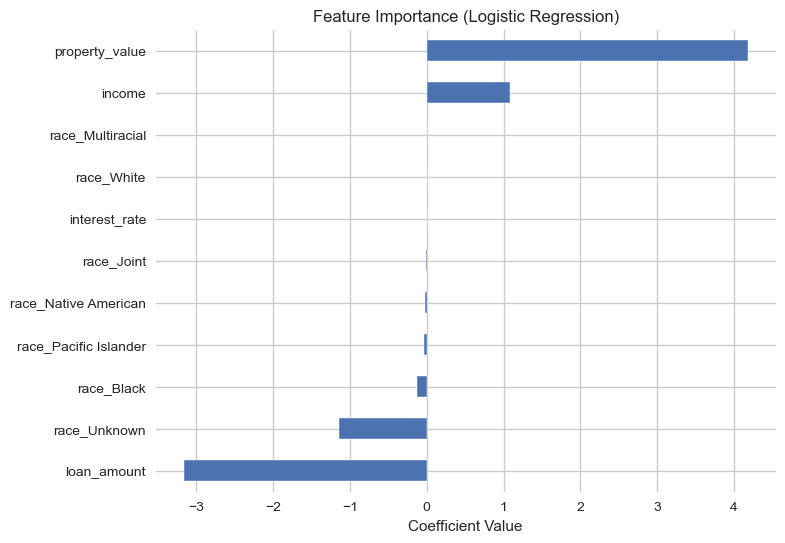

In [141]:
#Code Block 26
## feature importance for logistic regression baseline

coef_base = pd.Series(
    lr_model1.coef_[0],
    index=features_baseline
).sort_values()

print("Base Model Coefficients:")
print(coef_base)

coef_base.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.savefig("../../Analysis/figures/lr_baseline_fi.png", dpi=300, bbox_inches='tight')
plt.show()

### Continuous Covenant Logistic Regression

In [142]:
#Code Block 27
## train/test split for model with covenant count

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_cont, y, test_size=0.2, random_state=42
)

X_train2.to_csv('../../Analysis/X_train_continuous.csv', index=False)
X_test2.to_csv('../../Analysis/X_test_continuous.csv', index=False)
y_train2.to_csv('../../Analysis/y_train_continuous.csv', index=False)
y_test2.to_csv('../../Analysis/y_test_continuous.csv', index=False)

In [143]:
#Code Block 28
## scale the data and train the model with covenant count

scaler = StandardScaler()
X_train2_scaled = scaler.fit_transform(X_train2)
X_test2_scaled = scaler.transform(X_test2)

lr_model2 = LogisticRegression(max_iter=1000, random_state=42)
lr_model2.fit(X_train2_scaled, y_train2)

LogisticRegression(max_iter=1000, random_state=42)

In [144]:
#Code Block 29
## evaluate the model with covenant count

joblib.dump(lr_model2, '../../Analysis/models/lr_continuous.pkl')
y_pred2 = lr_model2.predict(X_test2_scaled)
print("Continuous Model Performance:")
print(classification_report(y_test2, y_pred2))
print("Confusion Matrix:")
print(confusion_matrix(y_test2, y_pred2))
print("Accuracy Score:", accuracy_score(y_test2, y_pred2))

Continuous Model Performance:
              precision    recall  f1-score   support

       False       0.64      0.59      0.62      3203
        True       0.90      0.92      0.91     12422

    accuracy                           0.85     15625
   macro avg       0.77      0.75      0.76     15625
weighted avg       0.84      0.85      0.85     15625

Confusion Matrix:
[[ 1891  1312]
 [ 1052 11370]]
Accuracy Score: 0.848704


Continuous Model Coefficients:
loan_amount             -3.150298
race_Unknown            -1.141248
race_Black              -0.126309
race_Pacific Islander   -0.036003
race_Native American    -0.020827
covenant_count          -0.008114
race_Joint              -0.004174
interest_rate            0.000011
race_White               0.003459
race_Multiracial         0.006008
income                   1.095777
property_value           4.162977
dtype: float64


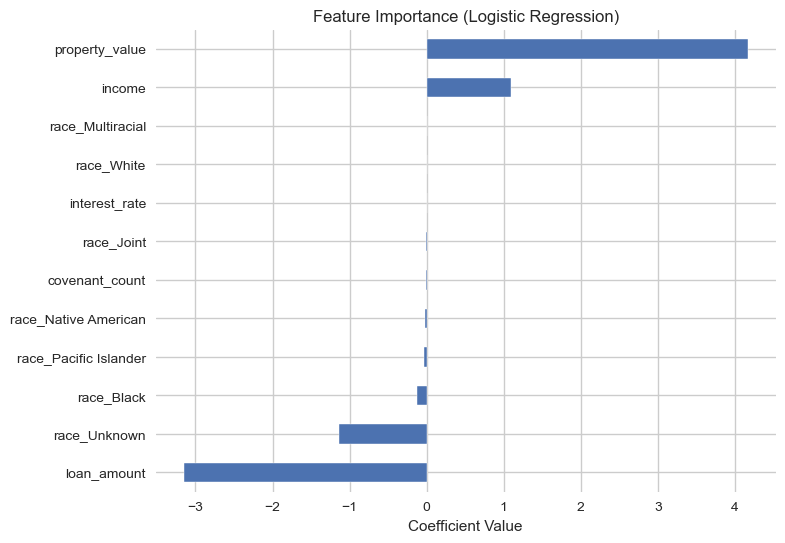

In [145]:
#Code Block 30
## feature importance for logistic regression continuous

coef_continuous = pd.Series(
    lr_model2.coef_[0],
    index=features_continuous
).sort_values()

print("Continuous Model Coefficients:")
print(coef_continuous)

coef_continuous.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.savefig("../../Analysis/figures/lr_continuous_fi.png", dpi=300, bbox_inches='tight')
plt.show()

### Covenant Density Logistic Regression

In [146]:
#Code Block 31
## train/test split for model with covenant density

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_dens, y, test_size=0.2, random_state=42
)

X_train3.to_csv('../../Analysis/X_train_density.csv', index=False)
X_test3.to_csv('../../Analysis/X_test_density.csv', index=False)
y_train3.to_csv('../../Analysis/y_train_density.csv', index=False)
y_test3.to_csv('../../Analysis/y_test_density.csv', index=False)

In [147]:
#Code Block 32
## scale the data and train the model with covenant density

scaler = StandardScaler()
X_train3_scaled = scaler.fit_transform(X_train3)
X_test3_scaled = scaler.transform(X_test3)

lr_model3 = LogisticRegression(max_iter=1000, random_state=42)
lr_model3.fit(X_train3_scaled, y_train3)

LogisticRegression(max_iter=1000, random_state=42)

In [148]:
#Code Block 33
## evaluate the model with covenant density

joblib.dump(lr_model3, '../../Analysis/models/lr_density.pkl')
y_pred3 = lr_model3.predict(X_test3_scaled)
print("Density Model Performance:")
print(classification_report(y_test3, y_pred3))
print("Confusion Matrix:")
print(confusion_matrix(y_test3, y_pred3))
print("Accuracy Score:", accuracy_score(y_test3, y_pred3))

Density Model Performance:
              precision    recall  f1-score   support

       False       0.64      0.59      0.62      3203
        True       0.90      0.92      0.91     12422

    accuracy                           0.85     15625
   macro avg       0.77      0.75      0.76     15625
weighted avg       0.84      0.85      0.85     15625

Confusion Matrix:
[[ 1895  1308]
 [ 1054 11368]]
Accuracy Score: 0.848832


Density Model Coefficients:
loan_amount             -3.157700
race_Unknown            -1.142519
race_Black              -0.125726
race_Pacific Islander   -0.036095
cd_Medium (51-100)      -0.022623
race_Native American    -0.020478
cd_Low (1-50)           -0.018504
cd_Very High (>200)     -0.014162
cd_High (101-200)       -0.005824
race_Joint              -0.004480
interest_rate            0.000466
race_White               0.002049
race_Multiracial         0.005912
income                   1.098729
property_value           4.184206
dtype: float64


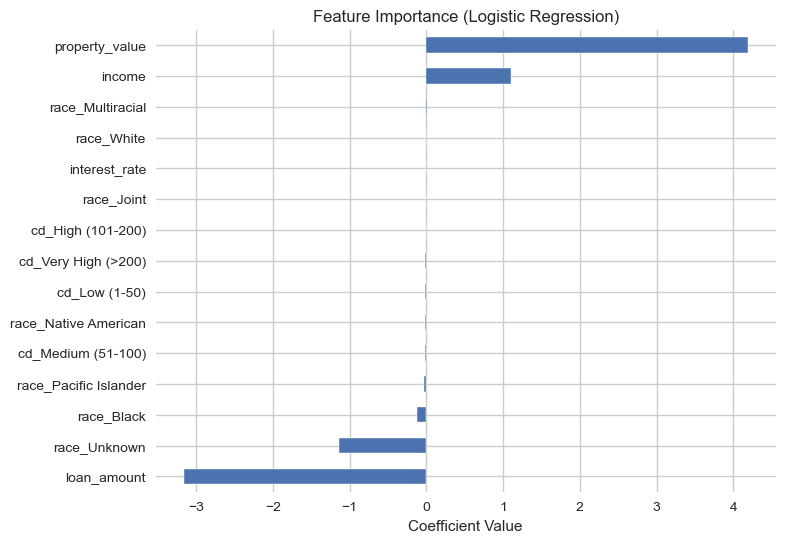

In [150]:
#Code Block 34
## feature importance for logistic regression density

coef_density = pd.Series(
    lr_model3.coef_[0],
    index=features_density
).sort_values()

print("Density Model Coefficients:")
print(coef_density)

coef_density.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.savefig("../../Analysis/figures/lr_density_fi.png", dpi=300, bbox_inches='tight')
plt.show()

### Interaction Effect

In [151]:
#Code Block 35
## features for interaction model

data_model['black_high_density'] = data_model['race_Black'] * data_model['cd_High (101-200)']
data_model['black_vhigh_density'] = data_model['race_Black'] * data_model['cd_Very High (>200)']
features_int = ['income', 'property_value', 'loan_amount', 'interest_rate', 'black_high_density', 'black_vhigh_density'] + race_dummies.columns.tolist() + density_dummies.columns.tolist()

## define target variable and features
y = data_model['was_approved']
X_int = data_model[features_int]

X_train4, X_test4, y_train4, y_test4 = train_test_split(
    X_int, y, test_size=0.2, random_state=42
)

X_train4.to_csv('../../Analysis/X_train_interaction.csv', index=False)
X_test4.to_csv('../../Analysis/X_test_interaction.csv', index=False)
y_train4.to_csv('../../Analysis/y_train_interaction.csv', index=False)
y_test4.to_csv('../../Analysis/y_test_interaction.csv', index=False)

In [152]:
#Code Block 36
## scale the data and train the model with covenant density

scaler = StandardScaler()
X_train4_scaled = scaler.fit_transform(X_train4)
X_test4_scaled = scaler.transform(X_test4)

lr_model4 = LogisticRegression(max_iter=1000, random_state=42)
lr_model4.fit(X_train4_scaled, y_train4)

LogisticRegression(max_iter=1000, random_state=42)

In [153]:
#Code Block 37
## evaluate the model with interaction terms

joblib.dump(lr_model4, '../../Analysis/models/lr_interaction.pkl')
y_pred4 = lr_model4.predict(X_test4_scaled)
print("Interaction Model Performance:")
print(classification_report(y_test4, y_pred4))
print("Confusion Matrix:")
print(confusion_matrix(y_test4, y_pred4))
print("Accuracy Score:", accuracy_score(y_test4, y_pred4))

Interaction Model Performance:
              precision    recall  f1-score   support

       False       0.64      0.59      0.62      3203
        True       0.90      0.92      0.91     12422

    accuracy                           0.85     15625
   macro avg       0.77      0.75      0.76     15625
weighted avg       0.84      0.85      0.85     15625

Confusion Matrix:
[[ 1895  1308]
 [ 1053 11369]]
Accuracy Score: 0.848896


Interaction Model Coefficients:
loan_amount             -3.156944
race_Unknown            -1.142522
race_Black              -0.128061
race_Pacific Islander   -0.036732
cd_Medium (51-100)      -0.022675
race_Native American    -0.020547
cd_Low (1-50)           -0.018032
cd_Very High (>200)     -0.016589
cd_High (101-200)       -0.006735
race_Joint              -0.004072
interest_rate            0.000580
race_White               0.001313
black_high_density       0.003322
race_Multiracial         0.005974
black_vhigh_density      0.015204
income                   1.097107
property_value           4.183102
dtype: float64


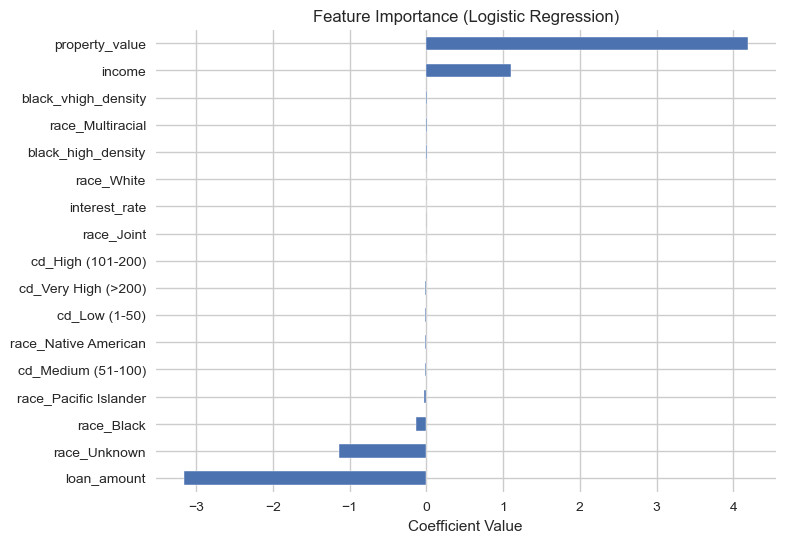

In [154]:
#Code Block 38
## feature importance for logistic regression with interaction terms

coef_interaction = pd.Series(
    lr_model4.coef_[0],
    index=features_int
).sort_values()

print("Interaction Model Coefficients:")
print(coef_interaction)

coef_interaction.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.savefig("../../Analysis/figures/lr_interaction_fi.png", dpi=300, bbox_inches='tight')
plt.show()